# Sree Ram Roshan A S - 24BAD113

# Visualization of Activation Functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.linspace(-10, 10, 500)

In [ ]:
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

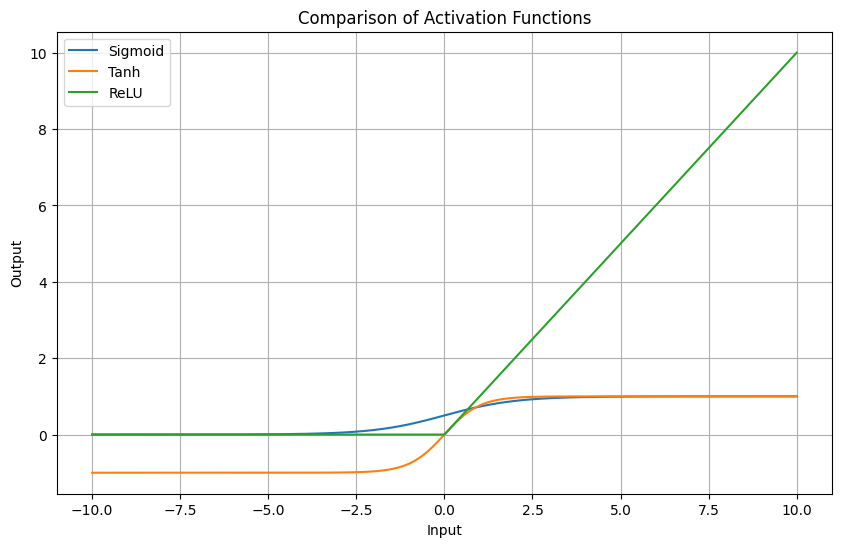

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')

plt.title("Comparison of Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

# Performance Comparison of Activation Functions

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,784)/255.0
X_test = X_test.reshape(-1,784)/255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

activations = ['sigmoid','tanh','relu']

results = {}


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for act in activations:

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation=act, input_shape=(784,)),
        tf.keras.layers.Dense(64, activation=act),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=128,
        verbose=1
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results[act] = acc

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7847 - loss: 0.9199 - val_accuracy: 0.9096 - val_loss: 0.3657
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9171 - loss: 0.3084 - val_accuracy: 0.9322 - val_loss: 0.2445
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9353 - loss: 0.2268 - val_accuracy: 0.9442 - val_loss: 0.1976
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9473 - loss: 0.1816 - val_accuracy: 0.9536 - val_loss: 0.1657
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9565 - loss: 0.1497 - val_accuracy: 0.9588 - val_loss: 0.1475
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8941 - loss: 0.3780 - val_accuracy: 0.9388 - val_loss: 0.2159
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9453 - loss: 0.1888 - val_accuracy: 0.9548 - val_loss: 0.1579
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9609 - loss: 0.1339 - val_accuracy: 0.9599 - v

In [ ]:
print("Activation Function Accuracy")

for k,v in results.items():
    print(k,"=",round(v*100,2),"%")

Activation Function Accuracy
sigmoid = 95.78 %
tanh = 97.03 %
relu = 97.34 %


# Comparison of Optimization Algorithms

In [ ]:
optimizers = {
    "SGD": lambda: tf.keras.optimizers.SGD(),
    "Momentum": lambda: tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": lambda: tf.keras.optimizers.RMSprop(),
    "Adam": lambda: tf.keras.optimizers.Adam()
}

In [ ]:
history_dict = {}

In [ ]:
for name, optimizer_fn in optimizers.items():

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer_fn(),   # <-- new optimizer each time
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=128,
        verbose=1
    )

    history_dict[name] = history

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

print(f"{name}")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Loss: {loss:.4f}")
print("-"*30)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6479 - loss: 1.3514 - val_accuracy: 0.8501 - val_loss: 0.6914
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8634 - loss: 0.5635 - val_accuracy: 0.8863 - val_loss: 0.4377
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8871 - loss: 0.4242 - val_accuracy: 0.8970 - val_loss: 0.3670
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8977 - loss: 0.3700 - val_accuracy: 0.9073 - val_loss: 0.3284
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9060 - loss: 0.3375 - val_accuracy: 0.9161 - val_loss: 0.3043
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8407 - loss: 0.5559 - val_accuracy: 0.9264 - val_loss: 0.2616
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9314 - loss: 0.2383 - val_accuracy: 0.9432 - val_loss: 0.2006
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9464 - loss: 0.1837 - val_accuracy: 0.9532 - v

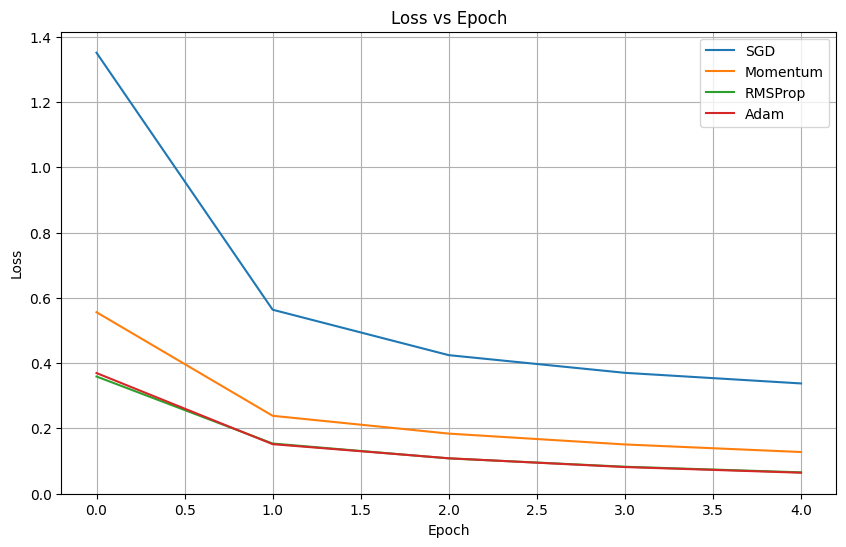

In [ ]:
plt.figure(figsize=(10,6))

for name,history in history_dict.items():
    plt.plot(history.history['loss'],label=name)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

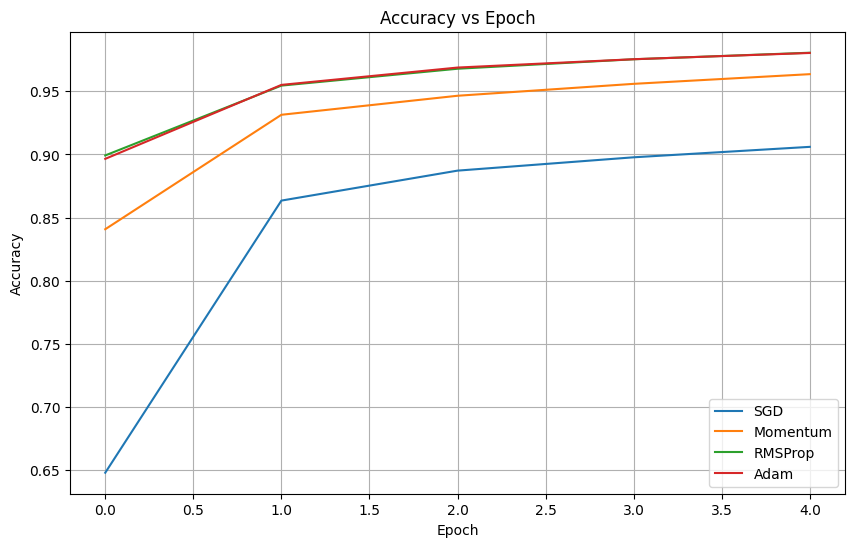

In [ ]:
plt.figure(figsize=(10,6))

for name,history in history_dict.items():
    plt.plot(history.history['accuracy'],label=name)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Deep Learning Experiment Management

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/MyDrive/ANN_Model.h5')

In [1]:
!git clone https://github.com/jackso1328/24ADI006-Deep-Learning.git

Cloning into '24ADI006-Deep-Learning'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 11 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 7.73 KiB | 1.93 MiB/s, done.


In [9]:
!cp "/content/drive/MyDrive/Colab Notebooks/DL_LAB_2.ipynb" "/content/24ADI006-Deep-Learning/Lab 2/"

In [10]:
!ls "/content/24ADI006-Deep-Learning/Lab 2"

 DL_LAB_2.ipynb  'New Text Document.txt'


In [11]:
%cd "/content/24ADI006-Deep-Learning"

/content/24ADI006-Deep-Learning


In [12]:
!git config --global user.name "jackso1328"
!git config --global user.email "jackso1328@gmail.com"

In [13]:
!git add .
!git commit -m "Added DL Lab 2 notebook"

[main a499e6c] Added DL Lab 2 notebook
 1 file changed, 1 insertion(+)
 create mode 100644 Lab 2/DL_LAB_2.ipynb
